In [5059]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

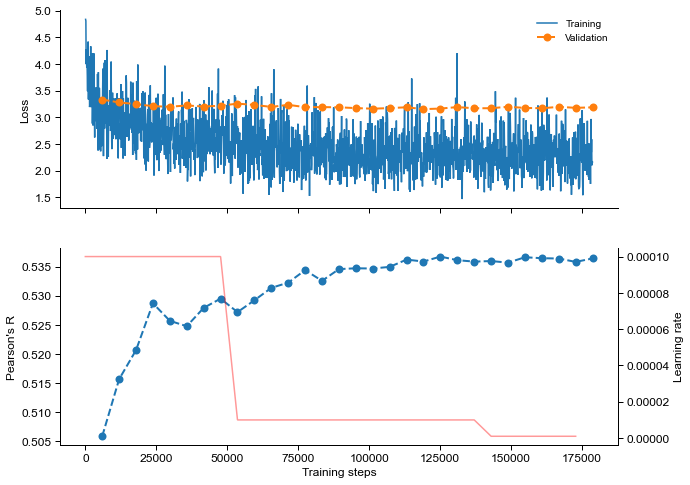

In [9276]:
metrics = pd.read_csv(
    "models/variant_data_AUG3_with_warmup_and_decay_v2/logs/lightning_logs/version_0/metrics.csv"
)

i = metrics.loss.abs() > 100
metrics.loc[i, "loss"] = pd.NA

val_steps = ~metrics.val_loss.isna()
val_metrics = metrics[val_steps]
train_metrics = metrics[~val_steps]

fig, ax = plt.subplots(2, 1, sharex=True)


i = ~np.isnan(metrics.loss)
ax[0].plot(metrics.step[i], metrics.loss[i], label="Training")
ax[0].plot(
    val_metrics.step, val_metrics.val_loss, "o--", lw=2, ms=8, label="Validation"
)

ax[0].set_ylabel("Loss")
ax[0].legend()

# ax[0].set_ylim(10, 40)

ax[1].plot(val_metrics.step, val_metrics.val_pcc, "o--", lw=2, ms=8, label="Correlation")
ax[1].set_xlabel("Training steps")
ax[1].set_ylabel("Pearson's R")

i = ~np.isnan(metrics["lr"])

tax = ax[1].twinx()
tax.plot(metrics.step[i], metrics["lr"][i], color="red", alpha=0.4, label="Learning rate")
tax.set_ylabel("Learning rate")

ax[1].spines["right"].set_visible(True)

fig.set_size_inches(10, 8)

In [9277]:
val_metrics.sort_values(by="step")

,epoch,loss,lr,step,val_loss,val_pcc
60,0.0,NaN,NaN,5957,3.330237,0.505874
122,1.0,NaN,NaN,11915,3.277205,0.515678
183,2.0,NaN,NaN,17873,3.245276,0.520663
245,3.0,NaN,NaN,23831,3.206934,0.528703
306,4.0,NaN,NaN,29789,3.196450,0.525694
368,5.0,NaN,NaN,35747,3.220238,0.524770
430,6.0,NaN,NaN,41705,3.200340,0.527919
491,7.0,NaN,NaN,47663,3.215593,0.529506
553,8.0,NaN,NaN,53621,3.254516,0.527191
614,9.0,NaN,NaN,59579,3.230649,0.529223


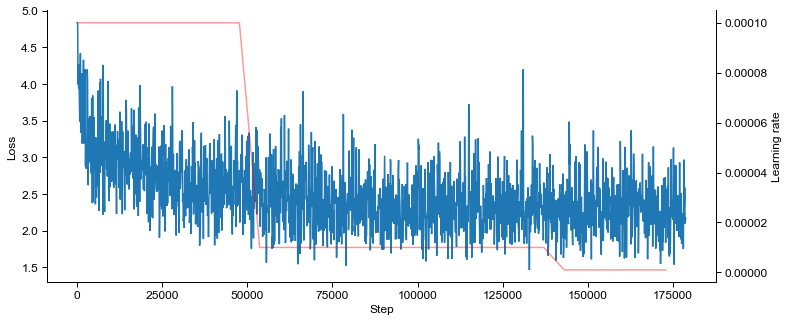

In [9278]:
fig, ax = plt.subplots()

i = ~np.isnan(metrics.loss)
ax.plot(metrics.step[i], metrics.loss[i])
ax.set_xlabel("Step")
ax.set_ylabel("Loss")

# ax.set_ylim(10, 40)
#
ax = ax.twinx()
i = ~np.isnan(metrics["lr"])
ax.plot(metrics.step[i], metrics["lr"][i], color="red", alpha=0.4)

ax.set_ylabel("Learning rate")

ax.spines["right"].set_visible(True)


fig.set_size_inches(12, 5)


In [9279]:
metrics

,epoch,loss,lr,step,val_loss,val_pcc
0,NaN,NaN,0.0001,0,NaN,NaN
1,0.0,4.834025,NaN,99,NaN,NaN
2,0.0,4.806078,NaN,199,NaN,NaN
3,0.0,3.994027,NaN,299,NaN,NaN
4,0.0,4.271211,NaN,399,NaN,NaN
...,...,...,...,...,...,...
1842,29.0,2.588508,NaN,178399,NaN,NaN
1843,29.0,2.099106,NaN,178499,NaN,NaN
1844,29.0,2.176335,NaN,178599,NaN,NaN
1845,29.0,2.162280,NaN,178699,NaN,NaN
